<a href="https://colab.research.google.com/github/HamzaEric/Heart_Diagnosis_MLP/blob/main/Notebooks/Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Backpropagation

Backpropagation is the conceptual algorithm. It is the overall strategy of working backward from the network's final error, applying the chain rule layer by layer to figure out how to update the weights.

Autograd (Automatic Differentiation) is the computational engine that automatically calculates the mathematical derivatives needed to train neural networks.

# How Autograd Works

1. **The Forward Pass Recording**: As data moves through the network (matrix multiplications, additions, ReLU activations), Autograd silently records every single mathematical operation in a dynamic computational graph.

2. **The Backward Pass (Backpropagation)**: Once the network calculates its final error (the loss), Autograd traverses the computational graph in reverse. It applies the chain rule backwards from the output to the input, computing how much each individual weight contributed to the final error.

3. **The Gradient**: The final output is the gradient for each weight. This tells the network's optimizer exactly which direction—and by how much—to adjust each specific parameter to lower the error on the next pass.


# Flow Direction

## Forward Pass ($\rightarrow$)

## $\mathbf{x} \rightarrow \mathbf{W}_1 \rightarrow z^{[1]} \rightarrow a^{[1]} \rightarrow \mathbf{W}_2 \rightarrow z^{[2]} \rightarrow a^{[2]} \rightarrow L$

##Backward Pass ($\leftarrow$)

## $\frac{\partial L}{\partial \mathbf{W}_1} \leftarrow \frac{\partial z^{[1]}}{\partial \mathbf{W}_1} \leftarrow \frac{\partial a^{[1]}}{\partial z^{[1]}} \leftarrow \frac{\partial z^{[2]}}{\partial a^{[1]}} \leftarrow \frac{\partial a^{[2]}}{\partial z^{[2]}} \leftarrow \frac{\partial L}{\partial a^{[2]}} \leftarrow L$

In [6]:
import numpy as np

# 1. Define the input and target
x_custom = np.array([[1.0, 3.0]])  # Shape: (1, 2)
y_custom = np.array([[2.0]])       # Shape: (1, 1)

# 2. Define weights and biases
# Using fixed seed for reproducible random weights
np.random.seed(42)
W1 = np.random.randn(2, 3)
b1 = np.random.randn(1, 3)
W2 = np.random.randn(3, 1)
b2 = np.random.randn(1, 1)

# 3. Define activation and its derivative
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    # Returns 1 if z > 0, else 0
    return (z > 0).astype(float)

# --- FORWARD PASS ---
z1 = x_custom @ W1 + b1          # Hidden linear
h = relu(z1)                     # Hidden activation
y_hat = h @ W2 + b2              # Output linear (assuming linear output, no sigmoid here)


dL_dyhat = y_hat - y_custom      # Shape: (1, 1)

dL_dW2 = h.T @ dL_dyhat          # Shape: (3, 1)
dL_db2 = dL_dyhat                # Shape: (1, 1)


dL_dh = dL_dyhat @ W2.T          # Shape: (1, 3)

dL_dz1 = dL_dh * relu_derivative(z1) # Shape: (1, 3)


dL_dW1 = x_custom.T @ dL_dz1     # Shape: (2, 3)
dL_db1 = dL_dz1                  # Shape: (1, 3)

print("Grad W2 shape:", dL_dW2.shape, "\n", dL_dW2, "\n")
print("Grad b2 shape:", dL_db2.shape, "\n", dL_db2, "\n")
print("Grad W1 shape:", dL_dW1.shape, "\n", dL_dW1, "\n")
print("Grad b1 shape:", dL_db1.shape, "\n", dL_db1)

Grad W2 shape: (3, 1) 
 [[12.27522432]
 [ 0.        ]
 [ 0.        ]] 

Grad b2 shape: (1, 1) 
 [[1.84728273]] 

Grad W1 shape: (2, 3) 
 [[1.0022618 0.        0.       ]
 [3.0067854 0.        0.       ]] 

Grad b1 shape: (1, 3) 
 [[ 1.0022618 -0.        -0.       ]]


In [7]:
# Initialize weights and biases again (reset)
np.random.seed(42)

x = np.array([[1.0, -1.0]])
y = np.array([[1.0]])

W1 = np.random.randn(2, 3)
b1 = np.random.randn(1, 3)
W2 = np.random.randn(3, 1)
b2 = np.random.randn(1, 1)

# Hyperparameters
lr = 0.1
epochs = 10
losses = []

# Training loop
for epoch in range(epochs):
    # ----- Forward pass -----
    z1 = x @ W1 + b1
    h = relu(z1)
    y_hat = h @ W2 + b2
    loss = 0.5 * (y_hat - y)**2
    losses.append(loss.item())

    # ----- Backward pass -----
    dL_dyhat = y_hat - y
    dL_dW2 = h.T @ dL_dyhat
    dL_db2 = dL_dyhat

    dL_dh = dL_dyhat @ W2.T
    dL_dz1 = dL_dh * relu_derivative(z1)
    dL_dW1 = x.T @ dL_dz1
    dL_db1 = dL_dz1


    # ----- Parameter update -----
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

Epoch 1: Loss = 0.5514
Epoch 2: Loss = 0.1787
Epoch 3: Loss = 0.0611
Epoch 4: Loss = 0.0203
Epoch 5: Loss = 0.0065
Epoch 6: Loss = 0.0020
Epoch 7: Loss = 0.0006
Epoch 8: Loss = 0.0002
Epoch 9: Loss = 0.0001
Epoch 10: Loss = 0.0000


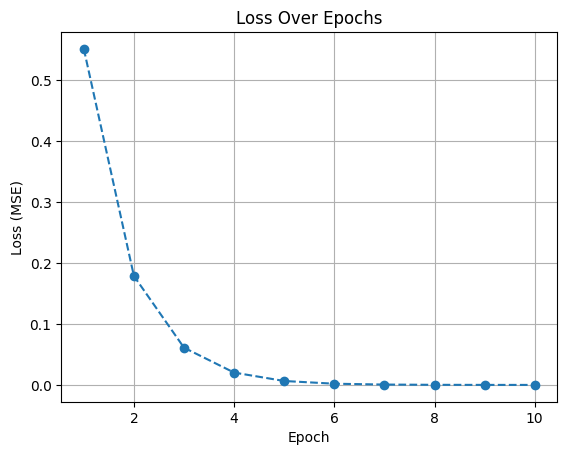

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), losses, marker='o', linestyle='--')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

In [10]:
predictions = []



# Reset weights
np.random.seed(42)
W1 = np.random.randn(2, 3)
b1 = np.random.randn(1, 3)
W2 = np.random.randn(3, 1)
b2 = np.random.randn(1, 1)

# Hyperparameters
lr = 0.1
epochs = 10
losses = []
predictions = []

# Input and target
x = np.array([[2.0, -1.0]])
y = np.array([[1.0]])

for epoch in range(epochs):
    # Forward pass
    z1 = x @ W1 + b1
    h = relu(z1)
    y_hat = h @ W2 + b2
    loss = 0.5 * (y_hat - y)**2

    losses.append(loss.item())
    predictions.append(y_hat.item())

    # Backward pass
    dL_dyhat = y_hat - y
    dL_dW2 = h.T @ dL_dyhat
    dL_db2 = dL_dyhat

    dL_dh = dL_dyhat @ W2.T
    dL_dz1 = dL_dh * relu_derivative(z1)
    dL_dW1 = x.T @ dL_dz1
    dL_db1 = dL_dz1

    # Update
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

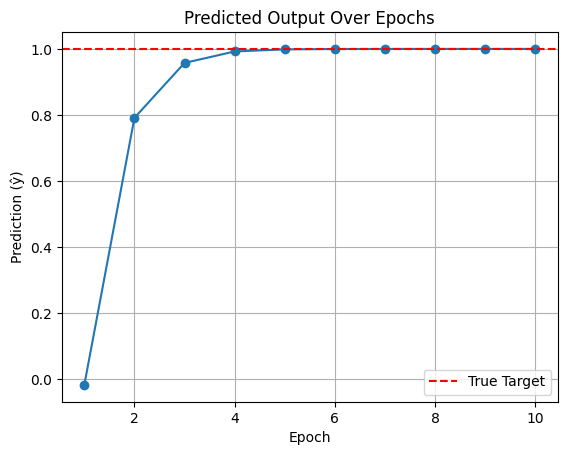

In [11]:
plt.plot(range(1, epochs + 1), predictions, marker='o')
plt.title("Predicted Output Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Prediction (ŷ)")
plt.grid(True)
plt.axhline(y=1.0, color='r', linestyle='--', label='True Target')
plt.legend()
plt.show()